✅ 2D Asset saved: ../../../assets\58_markov_2d.png


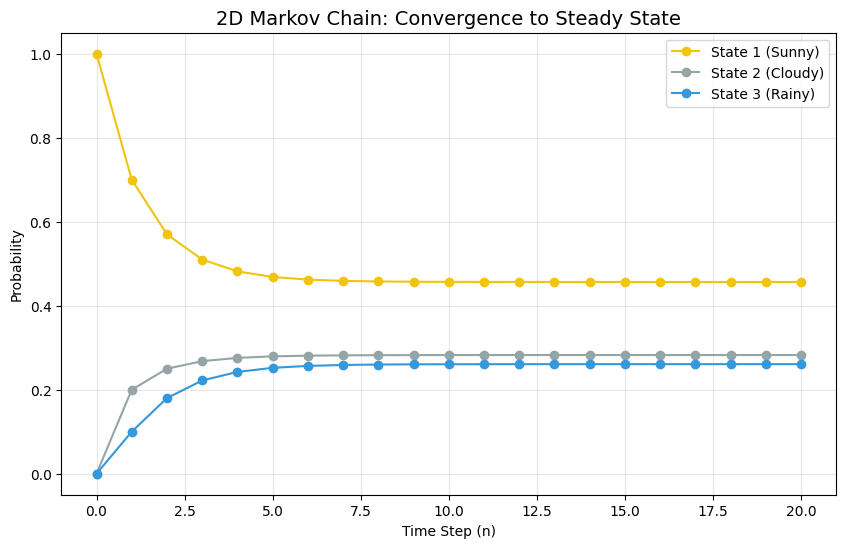

✅ 3D Asset saved: ../../../assets\58_markov_3d.png


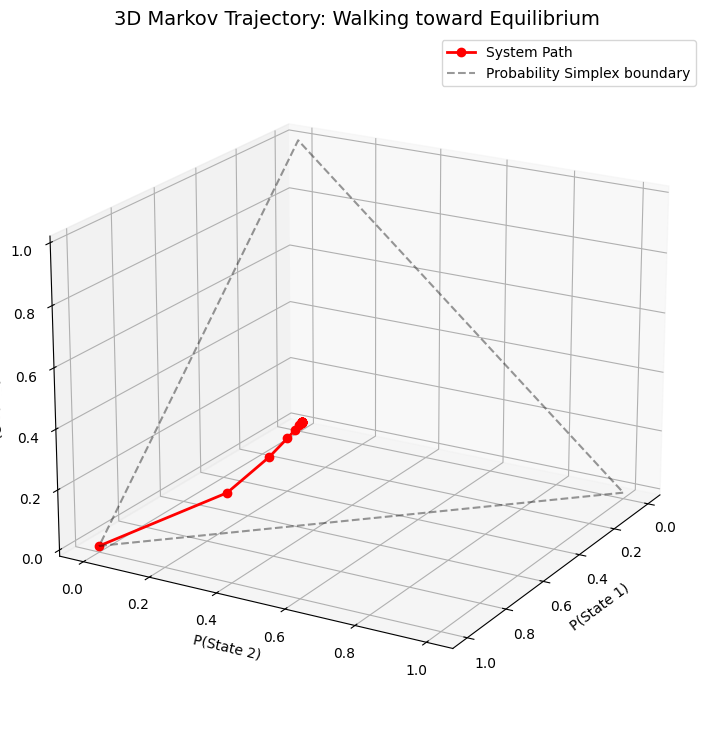

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def run_markov_master():
    # --- PROFESSIONAL PATH SETUP (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Define Transition Matrix (3x3 - e.g., Sunny, Cloudy, Rainy)
    # Rows sum to 1
    P = np.array([[0.7, 0.2, 0.1],
                  [0.3, 0.4, 0.3],
                  [0.2, 0.3, 0.5]])

    # 2. Simulation over 20 steps
    n_steps = 20
    state_dist = np.array([1.0, 0.0, 0.0]) # Start with 100% Sunny
    history = [state_dist]

    for _ in range(n_steps):
        state_dist = state_dist @ P
        history.append(state_dist)
    
    history = np.array(history)

    # --- 📸 ASSET 1: 2D EVOLUTION TO STEADY STATE (58_markov_2d.png) ---
    plt.figure(figsize=(10, 6))
    plt.plot(history[:, 0], 'o-', label='State 1 (Sunny)', color='#f1c40f')
    plt.plot(history[:, 1], 'o-', label='State 2 (Cloudy)', color='#95a5a6')
    plt.plot(history[:, 2], 'o-', label='State 3 (Rainy)', color='#3498db')
    
    plt.title("2D Markov Chain: Convergence to Steady State", fontsize=14)
    plt.xlabel("Time Step (n)"); plt.ylabel("Probability")
    plt.grid(alpha=0.3); plt.legend()
    
    save_path_2d = os.path.join(asset_path, '58_markov_2d.png')
    plt.savefig(save_path_2d, dpi=300)
    print(f"✅ 2D Asset saved: {save_path_2d}")
    plt.show()

    # --- 📸 ASSET 2: 3D SIMPLEX TRAJECTORY (58_markov_3d.png) ---
    fig = plt.figure(figsize=(12, 9))
    ax3d = fig.add_subplot(111, projection='3d')
    
    # Plot the trajectory in 3D probability space
    ax3d.plot(history[:, 0], history[:, 1], history[:, 2], 'r-o', markersize=6, lw=2, label='System Path')
    
    # Add a visual 'Simplex' plane (x+y+z = 1)
    x_s = [1, 0, 0, 1]
    y_s = [0, 1, 0, 0]
    z_s = [0, 0, 1, 0]
    ax3d.plot(x_s, y_s, z_s, 'k--', alpha=0.4, label='Probability Simplex boundary')

    ax3d.set_title("3D Markov Trajectory: Walking toward Equilibrium", fontsize=14)
    ax3d.set_xlabel("P(State 1)"); ax3d.set_ylabel("P(State 2)"); ax3d.set_zlabel("P(State 3)")
    ax3d.legend()
    
    ax3d.view_init(elev=20, azim=30)

    save_path_3d = os.path.join(asset_path, '58_markov_3d.png')
    plt.savefig(save_path_3d, dpi=300)
    print(f"✅ 3D Asset saved: {save_path_3d}")
    plt.show()

if __name__ == "__main__":
    run_markov_master()